# Loan Payback Prediction

This project analyzes loan repayment behavior using historical data to identify patterns associated with loan defaults. Exploratory Data Analysis is performed to understand borrower credit characteristics and loan features influencing repayment outcomes. A Decision Tree/Random Forest classifier will be used to model the binary target variable representing loan repayment status. Model results aim to support data-driven credit risk assessment.

### Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Loading the Data

In [2]:
df = pd.read_csv("D:/TopMentor Class Notes & Material/Datasets/Loan payback prediction/train.csv")
df.head(9)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0
6,6,61574.16,0.042,696,16907.71,13.52,Other,Single,High School,Self-employed,Debt consolidation,C5,1.0
7,7,45953.31,0.100,654,10111.62,12.82,Female,Married,High School,Employed,Home,D1,1.0
8,8,30592.29,0.132,713,7522.36,9.48,Male,Married,Bachelor's,Employed,Education,C5,1.0


### Data Auditing

In [3]:
df.shape

(593994, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [5]:
df.isna().sum().sort_values(ascending=False)
(df.isna().mean() * 100).sort_values(ascending=False)

id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
loan_paid_back          0.0
dtype: float64

In [6]:
duplicate_values = df.duplicated()
# Print the duplicate values if any duplicates exist, otherwise print 0
if duplicate_values.any():  # Check if any value in the Series is True
    print(duplicate_values)
else:
    print(0)

0


In [7]:
df.nunique()

id                      593994
annual_income           119728
debt_to_income_ratio       526
credit_score               399
loan_amount             111570
interest_rate             1454
gender                       3
marital_status               4
education_level              5
employment_status            5
loan_purpose                 8
grade_subgrade              30
loan_paid_back               2
dtype: int64

## Exploratory Data Analysis (EDA)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442235,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


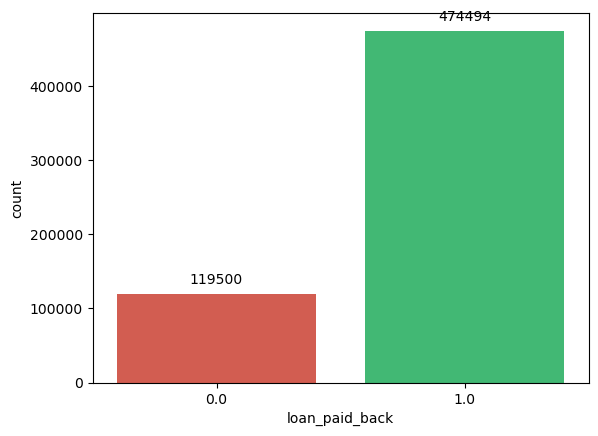

In [9]:
ax = sns.countplot(
    x='loan_paid_back',
    data=df,
    hue='loan_paid_back',
    palette={0.0: '#e74c3c', 1.0: '#2ecc71'},
    legend=False
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 5),
        textcoords='offset points'
    )
plt.show()

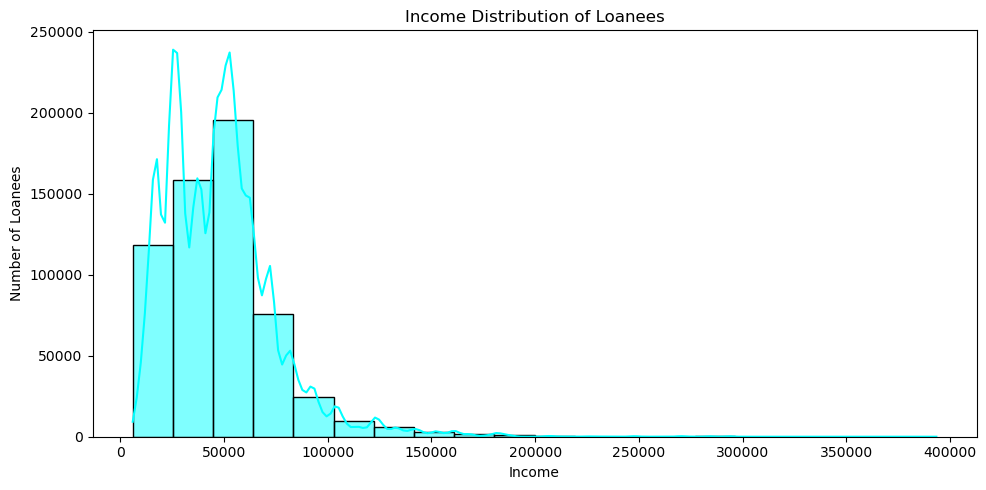

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df["annual_income"], kde=True, bins=20, color='cyan')
plt.title("Income Distribution of Loanees")
plt.xlabel("Income")
plt.ylabel("Number of Loanees")
plt.tight_layout()
plt.show()

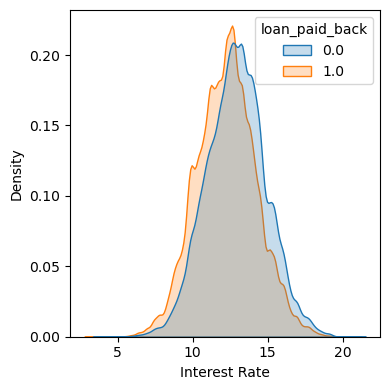

In [11]:
plt.figure(figsize=(4, 4))
sns.kdeplot(
    data=df,
    x='interest_rate',
    hue='loan_paid_back',
    fill=True,
    common_norm=False
)
plt.xlabel("Interest Rate")
plt.tight_layout()
plt.show()

Loans with higher interest rates show a greater likelihood of default, while successfully repaid loans are concentrated at lower interest rates. The overlap between distributions suggests interest rate is an important but not sufficient feature on its own.

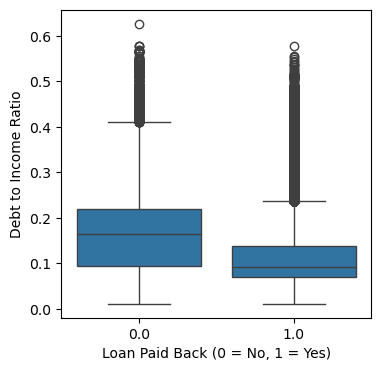

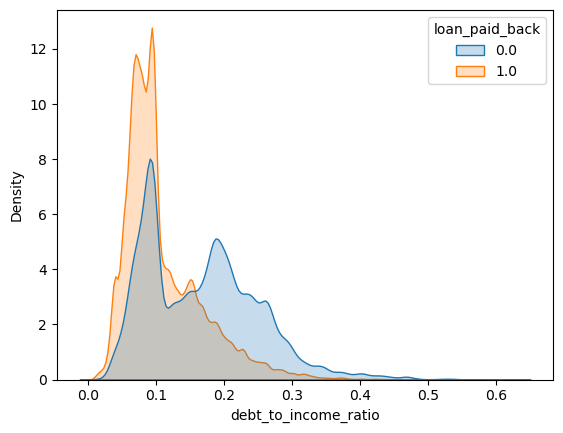

In [12]:
plt.figure(figsize=(4,4))
sns.boxplot(x='loan_paid_back', y='debt_to_income_ratio', data=df)
plt.xlabel("Loan Paid Back (0 = No, 1 = Yes)")
plt.ylabel("Debt to Income Ratio")
plt.show()

sns.kdeplot(
    data=df,
    x='debt_to_income_ratio',
    hue='loan_paid_back',
    fill=True,
    common_norm=False
)
plt.show()


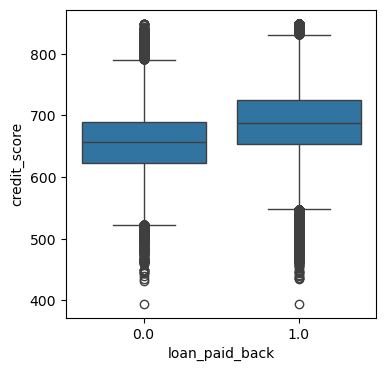

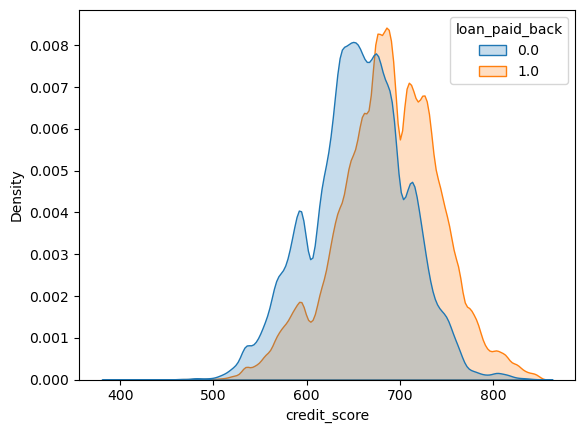

In [13]:
plt.figure(figsize=(4,4))
sns.boxplot(x='loan_paid_back', y='credit_score', data=df)
plt.show()

sns.kdeplot(
    data=df,
    x='credit_score',
    hue='loan_paid_back',
    fill=True,
    common_norm=False
)
plt.show()


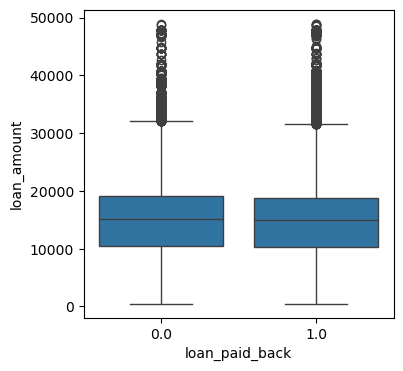

In [14]:
plt.figure(figsize=(4,4))
sns.boxplot(x='loan_paid_back', y='loan_amount', data=df)
plt.show()


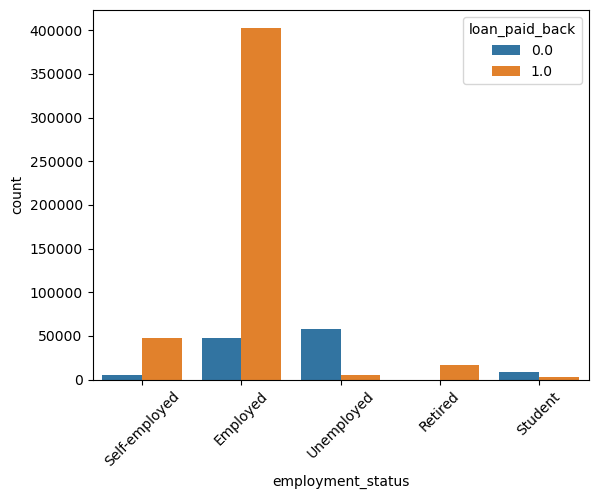

In [15]:
sns.countplot(
    x='employment_status',
    hue='loan_paid_back',
    data=df
)
plt.xticks(rotation=45)
plt.show()


In [16]:
def default_rate(df, feature):
    return (
        pd.crosstab(df[feature], df['loan_paid_back'], normalize='index')
        .sort_values(by=0, ascending=False)
    )


loan_paid_back       0.0       1.0
grade_subgrade                    
F3              0.395907  0.604093
F2              0.382279  0.617721
F1              0.375497  0.624503
F4              0.362963  0.637037
F5              0.360686  0.639314


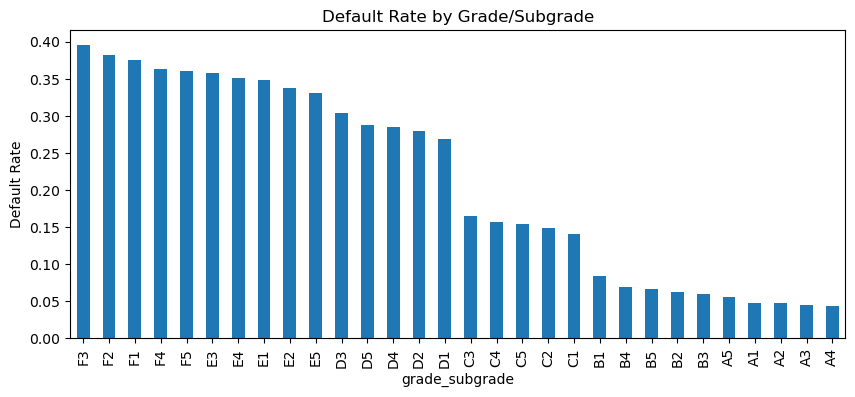

In [17]:
grade_default = default_rate(df, 'grade_subgrade')
print(grade_default.head())
grade_default[0].plot(kind='bar', figsize=(10,4))
plt.ylabel("Default Rate")
plt.title("Default Rate by Grade/Subgrade")
plt.show()


loan_paid_back        0.0       1.0
education_level                    
Bachelor's       0.211108  0.788892
Master's         0.197654  0.802346
Other            0.197211  0.802789
High School      0.190302  0.809698
PhD              0.169933  0.830067


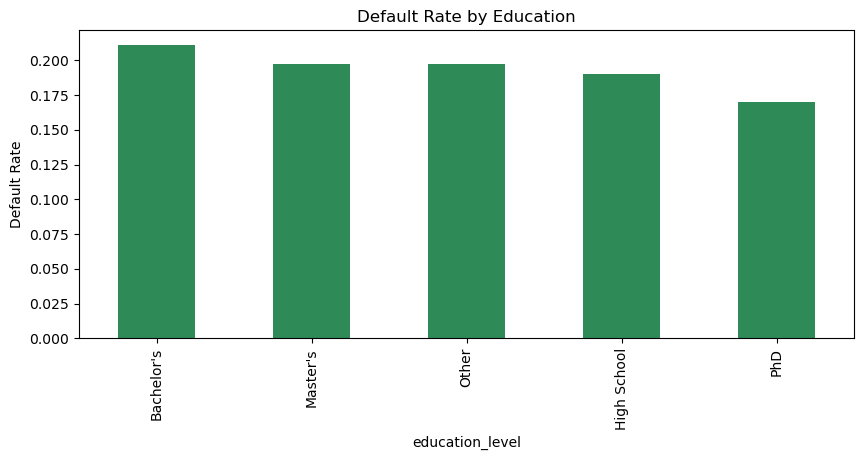

In [18]:
education_default = default_rate(df, 'education_level')
print(education_default.head())
education_default[0].plot(kind='bar', figsize=(10,4), color='seagreen')
plt.ylabel("Default Rate")
plt.title("Default Rate by Education")
plt.show()

loan_paid_back           0.0       1.0
loan_purpose                          
Education           0.222947  0.777053
Medical             0.221915  0.778085
Vacation            0.203929  0.796071
Debt consolidation  0.203089  0.796911
Car                 0.199370  0.800630


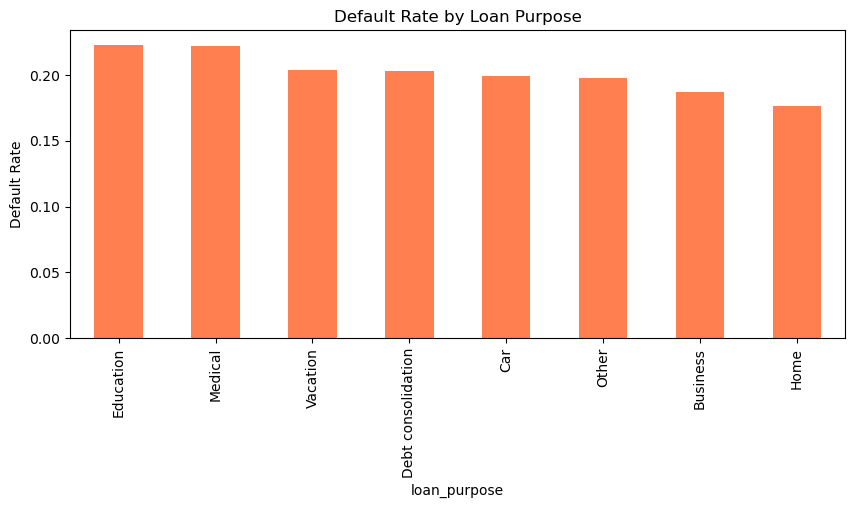

In [19]:
loanpurpose_default = default_rate(df, 'loan_purpose')
print(loanpurpose_default.head())
loanpurpose_default[0].plot(kind='bar', figsize=(10,4), color='coral')
plt.ylabel("Default Rate")
plt.title("Default Rate by Loan Purpose")
plt.show()

loan_paid_back       0.0       1.0
marital_status                    
Widowed         0.210152  0.789848
Divorced        0.203360  0.796640
Single          0.201127  0.798873
Married         0.200856  0.799144


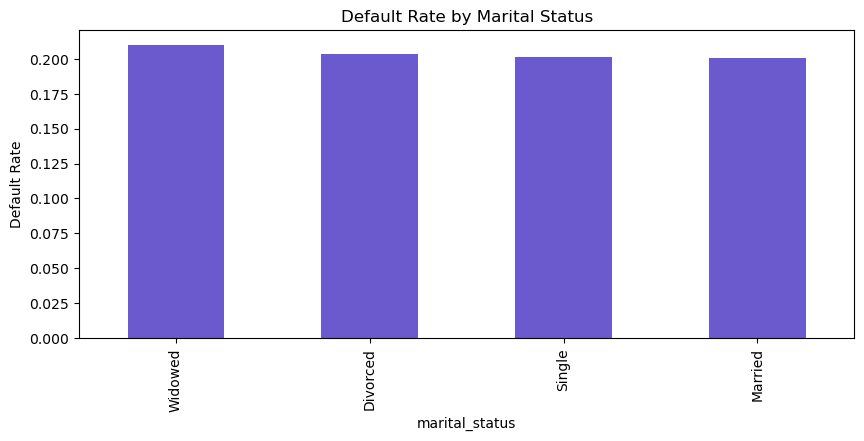

In [20]:
marital_default = default_rate(df, 'marital_status')
print(marital_default.head())
marital_default[0].plot(kind='bar', figsize=(10,4), color='slateblue')
plt.ylabel("Default Rate")
plt.title("Default Rate by Marital Status")
plt.show()

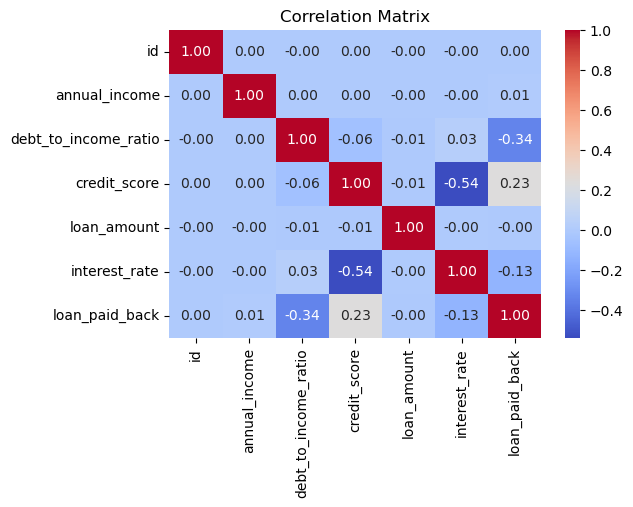

In [21]:
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

A correlation analysis was performed on numerical variables to identify linear relationships with the target variable. Credit score shows a positive correlation with loan repayment, while interest rate and debt-to-income ratio exhibit negative relationships.

In [22]:
df[['annual_income',
    'loan_amount',
    'interest_rate',
    'debt_to_income_ratio']].skew()


annual_income           1.719509
loan_amount             0.207360
interest_rate           0.049945
debt_to_income_ratio    1.406680
dtype: float64

Annual income and debt-to-income ratio exhibit strong positive skewness, indicating the presence of extreme values.

In [23]:
df['annual_income'] = np.log1p(df['annual_income'])
df['debt_to_income_ratio'] = np.log1p(df['debt_to_income_ratio'])

A log transformation is applied to reduce skewness and stabilize the distribution.

### Feature Engineering

In [24]:
df.drop(columns=['id'], inplace=True)
# dropped column id which is only an identifier, has no analytical significance

In [25]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

target = 'loan_paid_back'

num_features = [
    'annual_income',
    'debt_to_income_ratio',
    'credit_score',
    'loan_amount',
    'interest_rate'
]

cat_nominal = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose'
]

cat_ordinal = ['grade_subgrade']

grades = [
    'A1','A2','A3','A4','A5',
    'B1','B2','B3','B4','B5',
    'C1','C2','C3','C4','C5',
    'D1','D2','D3','D4','D5',
    'E1','E2','E3','E4','E5',
    'F1','F2','F3','F4','F5',
    'G1','G2','G3','G4','G5'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('grade', OrdinalEncoder(categories=[grades]), cat_ordinal),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int), cat_nominal),
        ('num', 'passthrough', num_features)
    ]
)

ColumnTransformer was used to apply ordinal encoding for ordered credit grades and one-hot encoding for nominal categorical variables, ensuring efficient preprocessing while preserving feature semantics.

## Modeling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [27]:
# defining x and y variables

X = df[num_features + cat_nominal+cat_ordinal]
y = df[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Stratifying target variable because it has imbalanced class distribution, this will ensure major class doesn't dominate training

In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [30]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('grade',
                                                  OrdinalEncoder(categories=[['A1',
                                                                              'A2',
                                                                              'A3',
                                                                              'A4',
                                                                              'A5',
                                                                              'B1',
                                                                              'B2',
                                                                              'B3',
                                                                              'B4',
                                                                              'B5',
                                                                              'C1',
                                                                              'C2',
                                                                              'C3',
                                                                              'C4',
                                                                              'C5',
                                                                              'D1',
                                                                              'D2',
                                                                              'D3',
                                                                              'D4',
                                                                              'D5',
                                                                              'E1',
                                                                              'E2',
                                                                              'E3',
                                                                              'E4',
                                                                              'E5',
                                                                              'F1',
                                                                              'F2',
                                                                              'F3',
                                                                              'F4',
                                                                              'F5', ...]]),
                                                  ['grade_subgrade']),
                                                 ('cat',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose']),
                                                 ('num', 'passthrough',
                                                  ['annual_income',
                                                   'debt_to_income_ratio',
                                                   'credit_score',
                                                   'loan_amount',
                                                   'interest_rate'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=20, n_jobs=-1,
                                        random_state=42))])

Implemented a preprocessing pipeline using ColumnTransformer to apply appropriate encoding techniques and integrated it with a Random Forest model to ensure consistent and leakage-free training.

In [31]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.65      0.77      0.70     23900
         1.0       0.94      0.90      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.83      0.81    118799
weighted avg       0.88      0.87      0.87    118799

ROC-AUC: 0.9134434191012414


In [32]:
# One-hot feature names
ohe_features = (
    model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out()
)

# Final feature list
all_features = (
    ['grade_subgrade'] +       # ordinal
    list(ohe_features) +       # one-hot
    num_features               # numeric
)

In [33]:
importances = model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
17,employment_status_Unemployed,0.283557
13,employment_status_Employed,0.221379
27,debt_to_income_ratio,0.207792
28,credit_score,0.067651
0,grade_subgrade,0.060425
15,employment_status_Self-employed,0.042353
16,employment_status_Student,0.039080
14,employment_status_Retired,0.029333
30,interest_rate,0.019707
29,loan_amount,0.009209


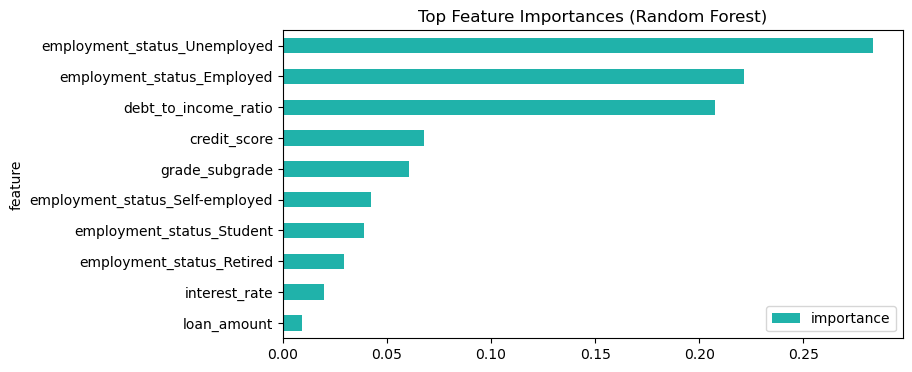

In [34]:
feature_importance.head(10).plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(8,4),
    color='lightseagreen'
)

plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.show()

In [35]:
def get_base_feature(col):
    if col.startswith('employment_status'):
        return 'employment_status'
    elif col.startswith('loan_purpose'):
        return 'loan_purpose'
    elif col.startswith('education_level'):
        return 'education_level'
    elif col.startswith('marital_status'):
        return 'marital_status'
    elif col.startswith('gender'):
        return 'gender'
    else:
        return col  

feature_importance['base_feature'] = feature_importance['feature'].apply(get_base_feature)

grouped_importance = (
    feature_importance
    .groupby('base_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

base_feature
employment_status       0.615702
debt_to_income_ratio    0.207792
credit_score            0.067651
grade_subgrade          0.060425
interest_rate           0.019707
loan_amount             0.009209
annual_income           0.008969
loan_purpose            0.003725
education_level         0.002800
marital_status          0.002206
gender                  0.001814
Name: importance, dtype: float64

Feature importance analysis shows that employment status is a strong predictor of loan repayment, followed by financial indicators such as debt-to-income ratio and credit score. However, the high importance of employment status may be amplified due to one-hot encoding, and core financial variables remain critical for reliable credit risk assessment.

In [36]:
pd.crosstab(df['employment_status'], df['loan_paid_back'], normalize='index')

loan_paid_back,0.0,1.0
employment_status,,
Employed,0.105855,0.894145
Retired,0.002796,0.997204
Self-employed,0.101543,0.898457
Student,0.736485,0.263515
Unemployed,0.922381,0.077619


Employment status emerges as the most influential predictor, with unemployed and student categories showing significantly higher default rates. This strong separation explains its high importance in the model. However, reliance on a single categorical variable should be interpreted cautiously, as real-world credit behavior is influenced by multiple financial factors.

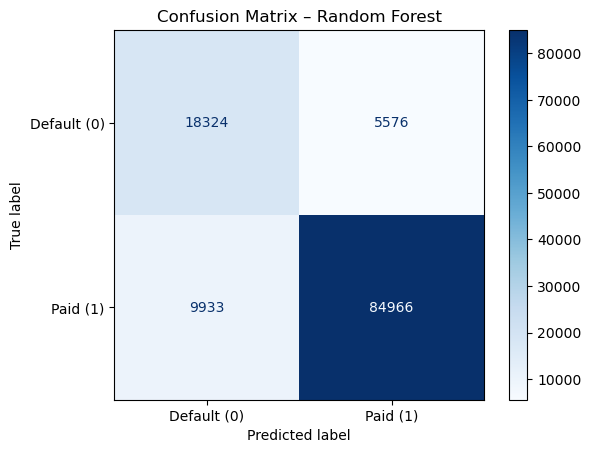

In [39]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default (0)", "Paid (1)"]
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.show()

The Random Forest model achieves strong overall accuracy and effectively identifies repaid loans. However, it misses a notable portion of default cases, which are critical in credit risk applications. This highlights the need to prioritize recall for the default class and potentially adjust the decision threshold.

In [39]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred_thresh = (y_prob > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.84      0.63      0.72     23900
         1.0       0.91      0.97      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.88      0.80      0.83    118799
weighted avg       0.90      0.90      0.90    118799


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.73      0.71      0.72     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.82      0.83    118799
weighted avg       0.89      0.89      0.89    118799


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.65      0.77      0.70     23900
         1.0       0.94      0.90      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.83      0.81    118799
weighted avg       0.88   

Threshold tuning was performed to improve detection of default cases. Increasing the threshold improves recall for defaulters, which is critical in credit risk. A threshold of 0.6 was selected as it provides a strong balance between identifying high-risk borrowers and maintaining overall model performance.     

At threshold 0.6, the model captures 82% of defaulters, significantly reducing risky loan approvals while maintaining acceptable accuracy.

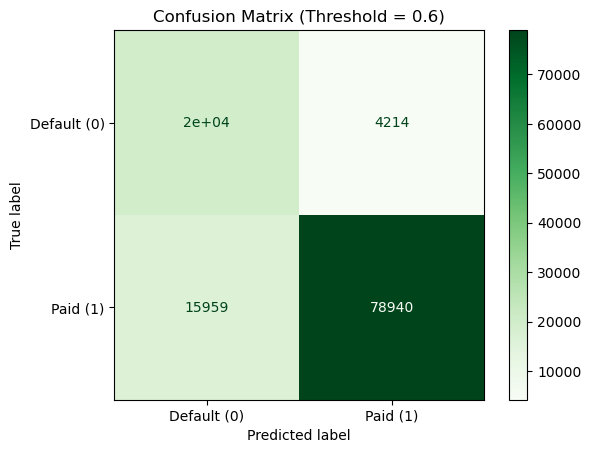

In [40]:
t = 0.6
y_pred_best = (y_prob > t).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default (0)", "Paid (1)"]
).plot(cmap='Greens')

plt.title(f"Confusion Matrix (Threshold = {t})")
plt.show()

Using a threshold of 0.6, the model significantly improves detection of defaulting borrowers, achieving a recall of over 80% for the default class. While this increases false positives, the trade-off is acceptable in credit risk applications, where avoiding risky loan approvals is more critical than incorrectly rejecting safe applicants.     

The model prioritizes minimizing financial losses by identifying high-risk borrowers more effectively, even at the cost of rejecting some low-risk applicants.

## Summary
This project analyzed loan repayment behavior using historical lending data to identify key factors influencing default risk. Exploratory Data Analysis revealed that variables such as employment status, debt-to-income ratio, credit score, and interest rate play a significant role in determining loan outcomes.

A Random Forest classifier was implemented with appropriate preprocessing using a ColumnTransformer, combining ordinal and one-hot encoding. Hyperparameter tuning improved model performance, achieving strong predictive capability as reflected in ROC-AUC and classification metrics.

Feature importance analysis showed that employment status is a dominant predictor, supported by observed default rates across categories, while financial indicators like debt-to-income ratio and credit score remain critical drivers. However, reliance on a single feature was carefully evaluated to ensure alignment with domain knowledge.

The confusion matrix highlighted that while the model performs well overall, some default cases are still missed. To address this, threshold tuning was explored to prioritize recall for defaulters, which is crucial in credit risk applications.

Overall, the model provides a robust framework for identifying high-risk borrowers and supports data-driven decision-making. Adjusting classification thresholds and incorporating business context can further enhance its practical applicability in financial risk management.